## AI-POWERED SKINCARE ANALYTICS SYSTEM

### 1.  Import Libraries


In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


# STYLE SETUP

plt.style.use("seaborn-v0_8-whitegrid")

plt.rcParams.update({
    'figure.figsize': (12, 6),
    'font.size': 11,
    'axes.titlesize': 14,
    'axes.titleweight': 'bold'
})

sns.set_palette("husl")

### 2. Load Data

In [37]:
df = pd.read_csv('../data/raw/skincare_dataset.csv')
df.head()

,UserID,Email,RegistrationDate,LastActive,Age,Gender,SkinType,SkinConcerns,FitzpatrickScale,Allergies,...,Microbiome_Health_Score,SunDamage_Risk,Aging_Signs_Score,Hydration_Level_pct,Oiliness_Level,PrescriptionRetinoid,AccutaneHistory,PregnancyBreastfeeding,ChemoHistory,DrugAllergies
0,DERMAI_000000,user1825@gmail.com,2026-04-18 14:54:55.322730,2026-05-05 14:54:55.763338,39,Female,Normal,Pigmentation,4,NaN,...,7,Medium,6,54,High,0,0,0,0,NaN
1,DERMAI_000001,user4507@gmail.com,2024-08-21 14:54:55.322730,2026-05-13 14:54:55.763338,32,Male,Combination,Pigmentation,5,Essential Oils,...,5,High,5,68,High,1,0,0,0,NaN
2,DERMAI_000002,user3658@gmail.com,2024-12-11 14:54:55.322730,2026-04-29 14:54:55.763338,41,Female,Oily,Pigmentation,5,NaN,...,5,Medium,7,55,Low,0,0,0,0,NaN
3,DERMAI_000003,user1680@hotmail.com,2025-09-21 14:54:55.322730,2026-04-19 14:54:55.763338,52,Male,Dry,Pigmentation,1,NaN,...,5,Medium,9,52,Medium,0,0,0,0,NaN
4,DERMAI_000004,user8936@gmail.com,2024-07-13 14:54:55.322730,2026-04-26 14:54:55.763338,31,Female,Oily,Dryness,4,NaN,...,6,Medium,4,49,Medium,0,0,0,0,Sulfa


###  3. Gender Distribution

In [47]:
df.columns

Index(['UserID', 'Email', 'RegistrationDate', 'LastActive', 'Age', 'Gender',
       'SkinType', 'SkinConcerns', 'FitzpatrickScale', 'Allergies', 'Country',
       'City', 'Climate', 'Humidity_pct', 'AvgTemperature_C', 'UV_Index',
       'Pollution_AQI', 'WaterHardness', 'SleepHours', 'StressLevel_1to10',
       'WaterIntake_Liters', 'Exercise_Weekly', 'Diet_Sugar', 'Smoking',
       'Alcohol', 'MakeupWear', 'CurrentCleanser', 'CleanserBrand',
       'CleanserPrice', 'CleanserRating', 'CleanserReviews',
       'CleanserIngredients', 'CurrentSerum', 'SerumBrand', 'SerumPrice',
       'SerumRating', 'SerumReviews', 'SerumIngredients', 'CurrentMoisturizer',
       'MoisturizerBrand', 'MoisturizerPrice', 'MoisturizerRating',
       'MoisturizerReviews', 'MoisturizerIngredients', 'CurrentSunscreen',
       'SunscreenSPF', 'UsesRetinol', 'UsesVitaminC', 'UsesNiacinamide',
       'UsesHyaluronicAcid', 'UsesSalicylicAcid', 'UsesGlycolicAcid',
       'UsesPeptides', 'UsesCeramides', 'ProductEffe

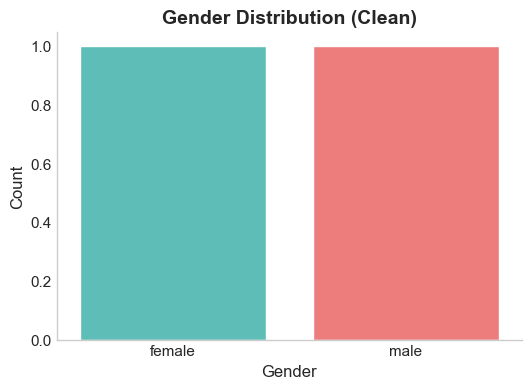

In [51]:
import matplotlib.pyplot as plt
import seaborn as sns

# Clean data (only male/female)
df_clean = df[df['Gender'].isin(['male', 'female'])]

gender_counts = df_clean['Gender'].value_counts()

plt.figure(figsize=(6,4))

sns.barplot(
    x=gender_counts.index,
    y=gender_counts.values,
    palette=["#4ECDC4", "#FF6B6B"]
)

plt.title("Gender Distribution (Clean)", fontsize=14, fontweight='bold')
plt.xlabel("Gender")
plt.ylabel("Count")

# Remove dark grid clutter
sns.despine()
plt.grid(False)

plt.show()

### 4. AGE DISTRIBUTION

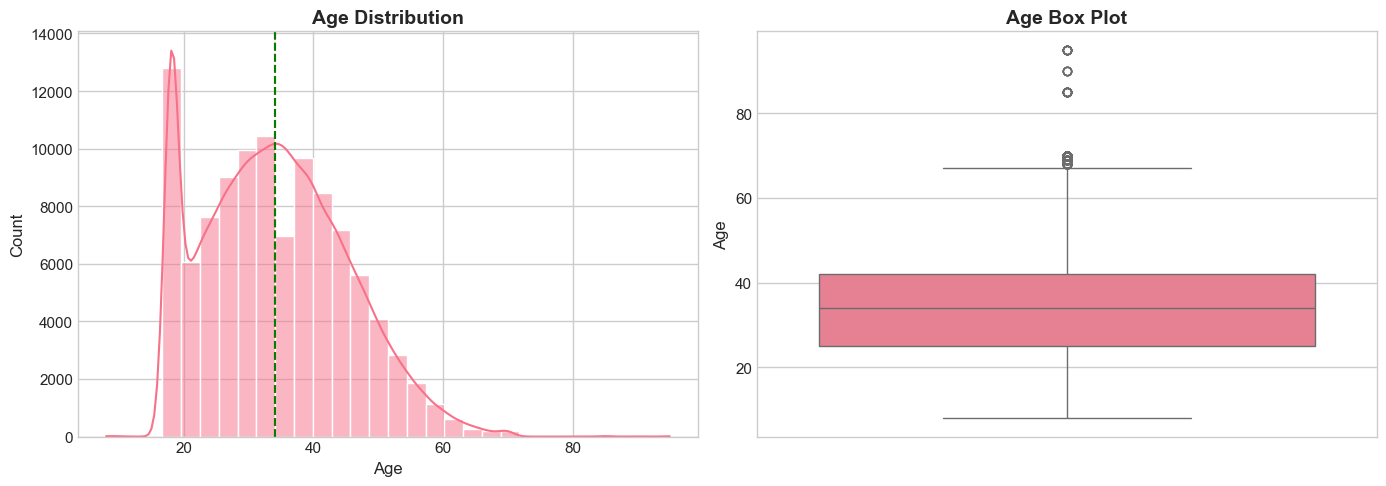

In [52]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df['Age'], bins=30, kde=True, ax=ax[0])
ax[0].axvline(df['Age'].mean(), color='red', linestyle='--')
ax[0].axvline(df['Age'].median(), color='green', linestyle='--')
ax[0].set_title("Age Distribution")

sns.boxplot(y=df['Age'], ax=ax[1])
ax[1].set_title("Age Box Plot")

plt.tight_layout()
plt.show()

### Skin Type

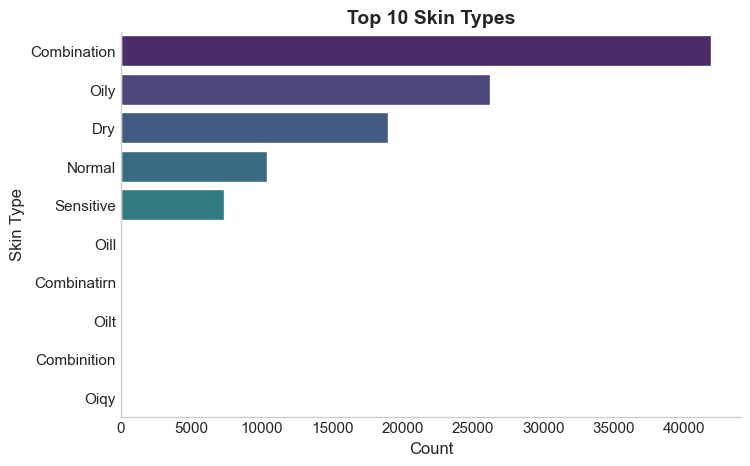

In [54]:
import matplotlib.pyplot as plt
import seaborn as sns

# Top 10 only
skin_counts = df['SkinType'].value_counts().head(10)

plt.figure(figsize=(8,5))

sns.barplot(
    x=skin_counts.values,
    y=skin_counts.index,
    palette="viridis"
)

plt.title("Top 10 Skin Types")
plt.xlabel("Count")
plt.ylabel("Skin Type")

sns.despine()
plt.grid(False)

plt.show()

### Budget Analysis

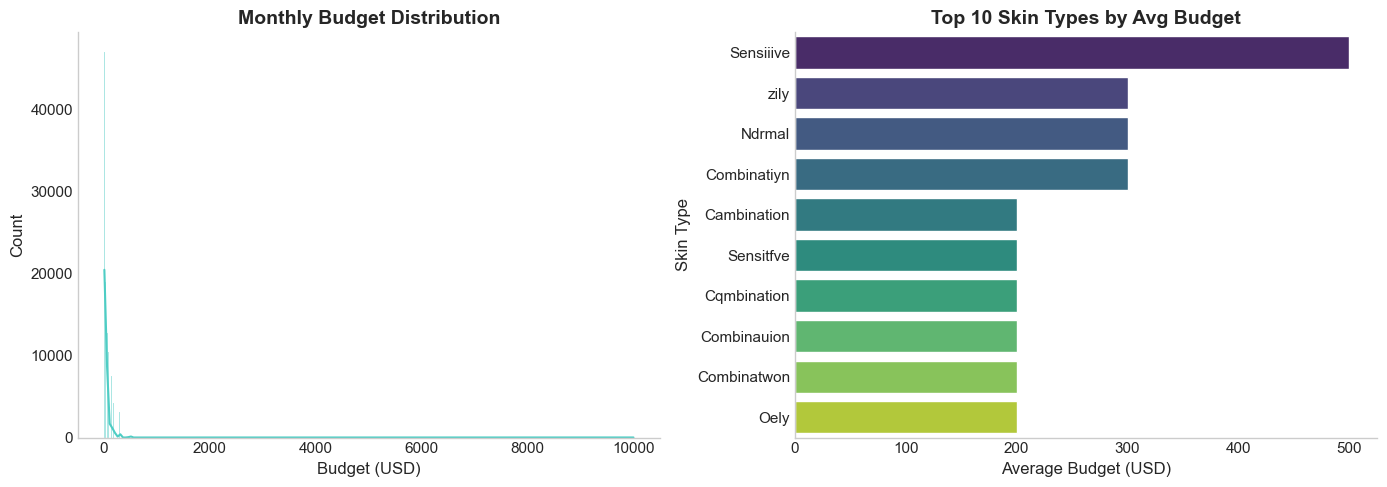

In [56]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# =========================
# 1. MONTHLY BUDGET DISTRIBUTION
# =========================
sns.histplot(
    df['MonthlyBudget_USD'],
    kde=True,
    ax=ax[0],
    color="#4ECDC4"
)

ax[0].set_title("Monthly Budget Distribution")
ax[0].set_xlabel("Budget (USD)")
ax[0].set_ylabel("Count")
sns.despine(ax=ax[0])
ax[0].grid(False)

# =========================
# 2. AVG BUDGET BY SKIN TYPE (TOP 10 ONLY)
# =========================
budget_by_skin = (
    df.groupby('SkinType')['MonthlyBudget_USD']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

sns.barplot(
    x=budget_by_skin.values,
    y=budget_by_skin.index,
    ax=ax[1],
    palette="viridis"
)

ax[1].set_title("Top 10 Skin Types by Avg Budget")
ax[1].set_xlabel("Average Budget (USD)")
ax[1].set_ylabel("Skin Type")

sns.despine(ax=ax[1])
ax[1].grid(False)

plt.tight_layout()
plt.show()



### 5. EFFECTIVENESS & SATISFACTION

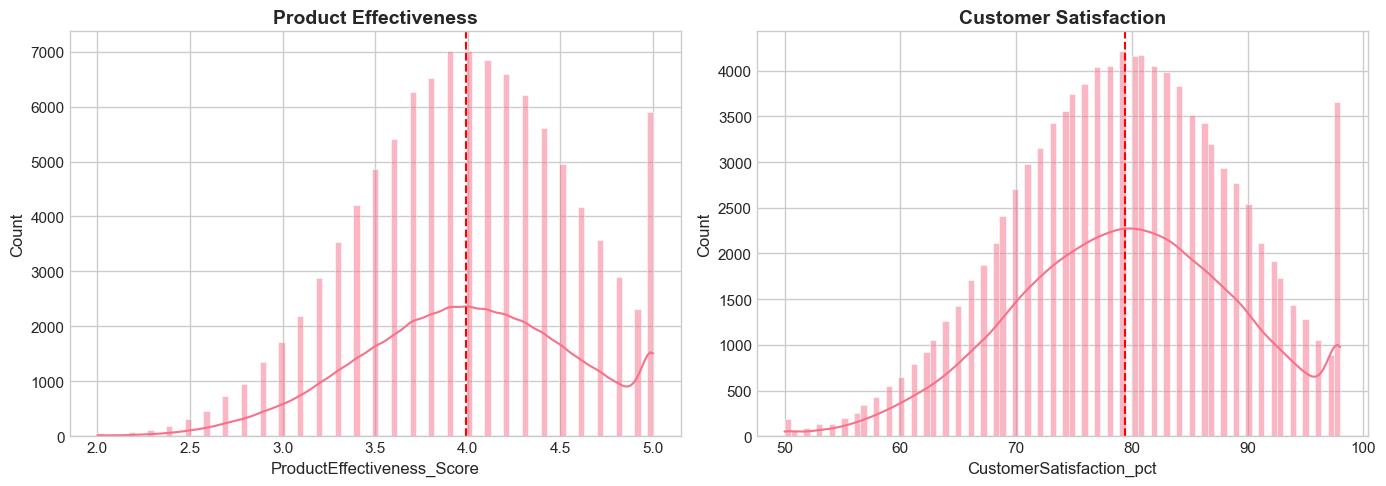

In [57]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df['ProductEffectiveness_Score'], kde=True, ax=ax[0])
ax[0].axvline(df['ProductEffectiveness_Score'].mean(), color='red', linestyle='--')
ax[0].set_title("Product Effectiveness")

sns.histplot(df['CustomerSatisfaction_pct'], kde=True, ax=ax[1])
ax[1].axvline(df['CustomerSatisfaction_pct'].mean(), color='red', linestyle='--')
ax[1].set_title("Customer Satisfaction")

plt.tight_layout()
plt.show()


### 6. CORRELATION MATRIX

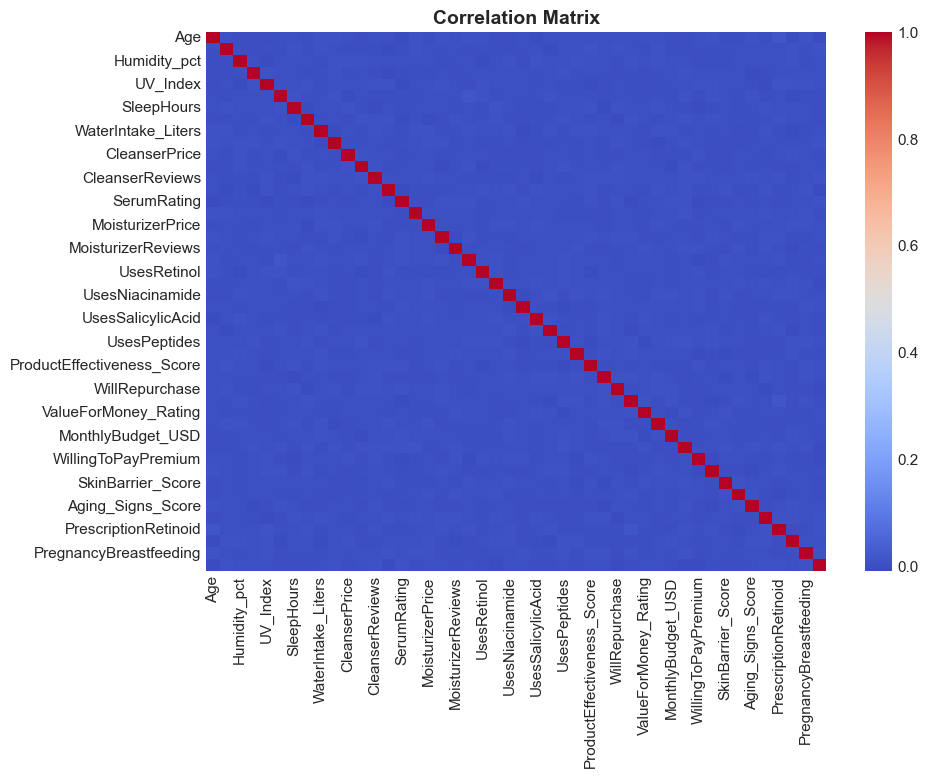

In [58]:
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(10, 7))
sns.heatmap(numeric_df.corr(), cmap="coolwarm", annot=False)
plt.title("Correlation Matrix")
plt.show()


### 7. OUTLIER CHECK

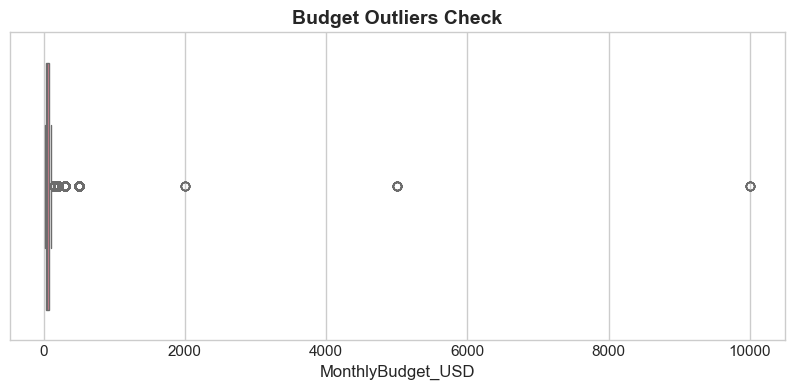

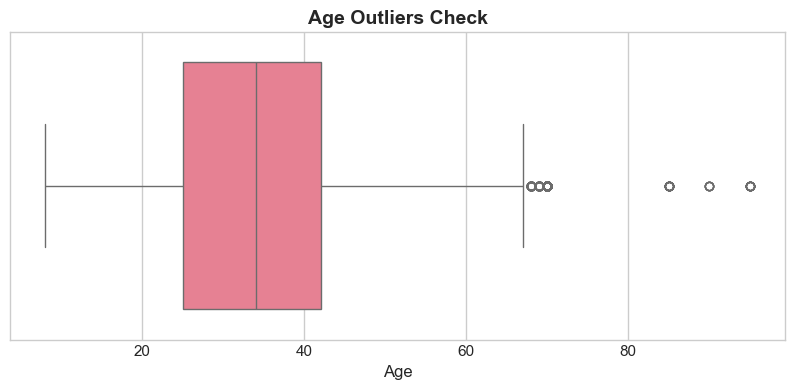

In [59]:
plt.figure(figsize=(10,4))
sns.boxplot(x=df['MonthlyBudget_USD'])
plt.title("Budget Outliers Check")
plt.show()

plt.figure(figsize=(10,4))
sns.boxplot(x=df['Age'])
plt.title("Age Outliers Check")
plt.show()

### 8. ACTIVE INGREDIENTS

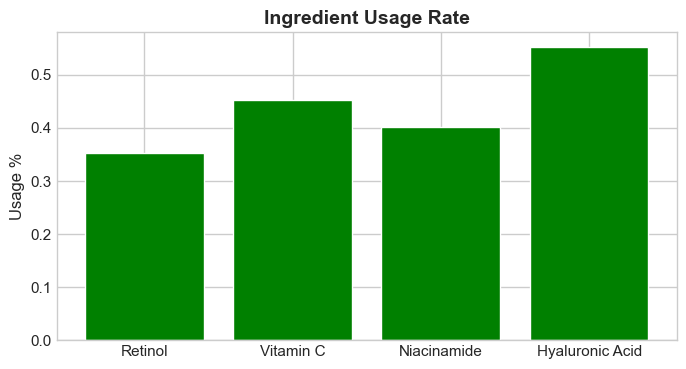

In [60]:
ingredients = {
    "Retinol": df['UsesRetinol'].mean(),
    "Vitamin C": df['UsesVitaminC'].mean(),
    "Niacinamide": df['UsesNiacinamide'].mean(),
    "Hyaluronic Acid": df['UsesHyaluronicAcid'].mean()
}

plt.figure(figsize=(8,4))
plt.bar(ingredients.keys(), ingredients.values(), color='green')
plt.title("Ingredient Usage Rate")
plt.ylabel("Usage %")
plt.show()

### 9. REPURCHASE BEHAVIOR

###  9.1 By SkinType

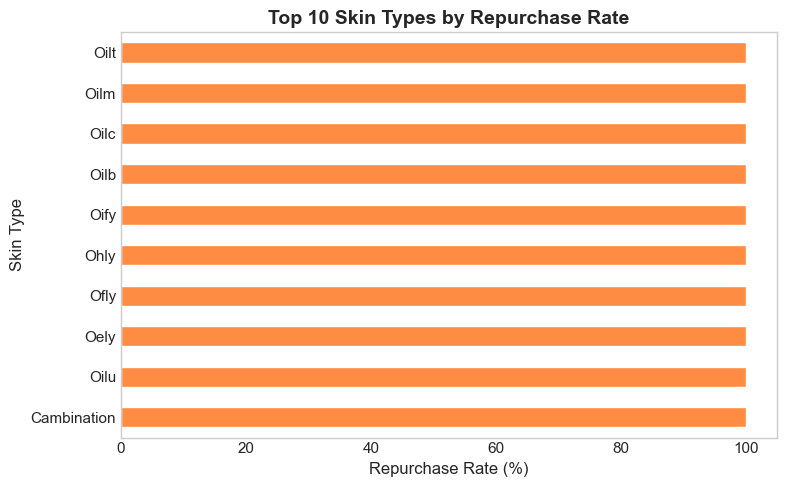

In [62]:
import matplotlib.pyplot as plt

# Repurchase rate by skin type (%)
repurchase_skin = (
    df.groupby('SkinType')['WillRepurchase']
    .mean()
    .mul(100)
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(8,5))

repurchase_skin.sort_values().plot(
    kind='barh',
    color="#FF8C42"
)

plt.title("Top 10 Skin Types by Repurchase Rate")
plt.xlabel("Repurchase Rate (%)")
plt.ylabel("Skin Type")

plt.grid(False)
plt.tight_layout()

plt.show()

###  9.2 By Budget Segment

In [68]:
import numpy as np

df['BudgetSegment'] = pd.cut(
    df['MonthlyBudget_USD'],
    bins=[0, 50, 100, 200, 500, 1000, np.inf],
    labels=['Very Low', 'Low', 'Medium', 'High', 'Very High', 'Luxury']
)

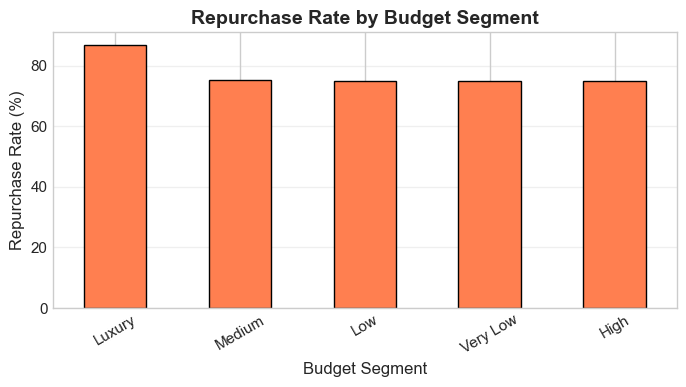

In [69]:
import matplotlib.pyplot as plt

repurchase_budget = (
    df.groupby('BudgetSegment')['WillRepurchase']
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

plt.figure(figsize=(7,4))

repurchase_budget.plot(
    kind='bar',
    color='coral',
    edgecolor='black'
)

plt.title("Repurchase Rate by Budget Segment")
plt.xlabel("Budget Segment")
plt.ylabel("Repurchase Rate (%)")

plt.xticks(rotation=30)
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

### 10. INTERACTIVE 

### 10.1. 3D Scatter

In [3]:
import pandas as pd

df = pd.read_csv("../data/raw/skincare_dataset.csv")
import plotly.express as px

sample = df.sample(n=min(1000, len(df)), random_state=42)

fig = px.scatter_3d(
    sample,
    x='Age',
    y='MonthlyBudget_USD',
    z='CustomerSatisfaction_pct',
    color='SkinType',
    size='ProductEffectiveness_Score'
)

fig.show()


### KEY INSIGHTS

In [6]:
print("KEY INSIGHTS")
print("-" * 40)

# Basic stats
print("Average Age:", round(df['Age'].mean(), 2))
print("Average Budget:", round(df['MonthlyBudget_USD'].mean(), 2))

# Modes
print("Top Skin Type:", df['SkinType'].mode()[0])

top_concern = df['SkinConcerns'].str.split(',').explode().mode()[0]
print("Top Concern:", top_concern)

# Ingredient handling (safe check)
if 'ingredients' in globals():
    best_ing = max(ingredients, key=ingredients.get)
    print("Most Used Ingredient:", best_ing)
else:
    print("Most Used Ingredient: Not calculated (ingredients dict missing)")

# Repurchase rate (robust)
if df['WillRepurchase'].dtype == 'O':
    repurchase_rate = df['WillRepurchase'].map({'Yes': 1, 'No': 0}).mean() * 100
else:
    repurchase_rate = df['WillRepurchase'].mean() * 100

print("Repurchase Rate:", round(repurchase_rate, 2), "%")

KEY INSIGHTS
----------------------------------------
Average Age: 34.08
Average Budget: 73.01
Top Skin Type: Combination
Top Concern: Acne
Most Used Ingredient: Not calculated (ingredients dict missing)
Repurchase Rate: 74.87 %
